# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



# Answers:

* 1: Out of years at the company, hours worked, and focus score there is a clear winner. Years at the company and hours worked have no clear trend, with both having many outliers and essentially being just a blob with no relevance, reaching only 0.003 and 0.00 R-Squared. However, Focus score has a direct correlation between higher focus and higher productivity and an R-squared of 0.678, which isn't perfect, but is very good in comparison.

* 2: Based on research and expirimentatin, the best model would analyze the FocusScore, DeskLocation, HoursWorked, TeamMeetingsPerWeek. These factors bring the R-Squared up to 0.683, which is only about 0.006 higher thanjust taking the focus score, however it is an increase.

* 3: The only two datapoints that seem to have any real impact are the focus score and (minorly) the Desk Location. Focus score is derectly tied to the productivity score, whereas employees located in the open plan have a slightly higher average productivity at all focus levels except for the very top. When looking over the data with the employee complaints in mind, the data contradicts most of the points given, with the only real merit going to the managers concerns with remote workers, which is only slightly.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


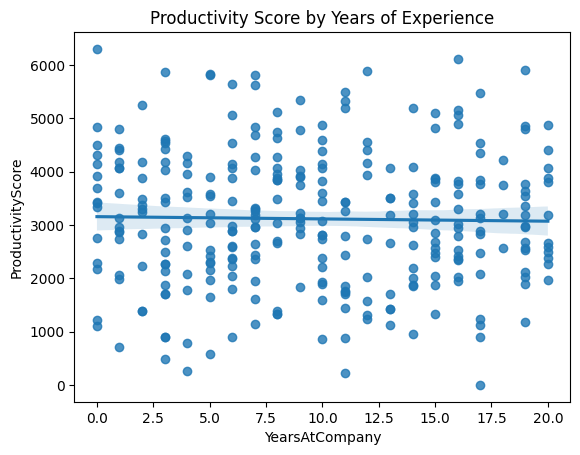

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1227
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.726
Time:                        14:47:51   Log-Likelihood:                -2564.1
No. Observations:                 300   AIC:                             5132.
Df Residuals:                     298   BIC:                             5140.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3154.6734    136.338     23.139      0.000    2886.366    3422.981
YearsAtCompany    -4.2493     12.132     -0.350      0.726     -28.124      19.625
==============================================================================
Omnibus:                        2.338   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.311   Jarque-Bera (JB):                2.025
Skew:                           0.091   Prob(JB):                        0.363
Kurtosis:                       2.641   Cond. No.                         21.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [25]:
sns.regplot(x='YearsAtCompany', y='ProductivityScore', data=df)
plt.title('Productivity Score by Years of Experience')
plt.show()

X = sm.add_constant(df['YearsAtCompany'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

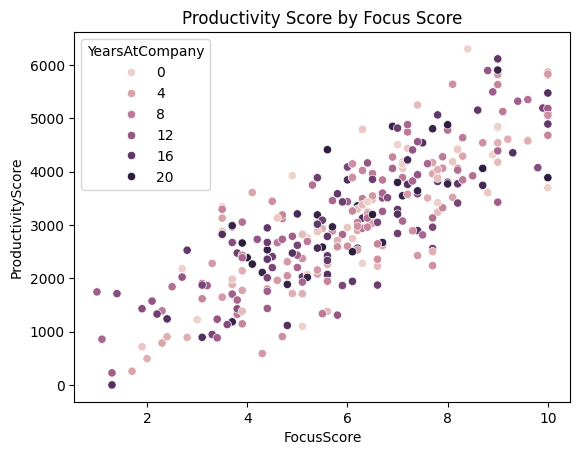

In [26]:
sns.scatterplot(x='FocusScore', y='ProductivityScore', hue='YearsAtCompany', data=df)
plt.title('Productivity Score by Focus Score')
plt.show()

<Axes: xlabel='FocusScore', ylabel='ProductivityScore'>

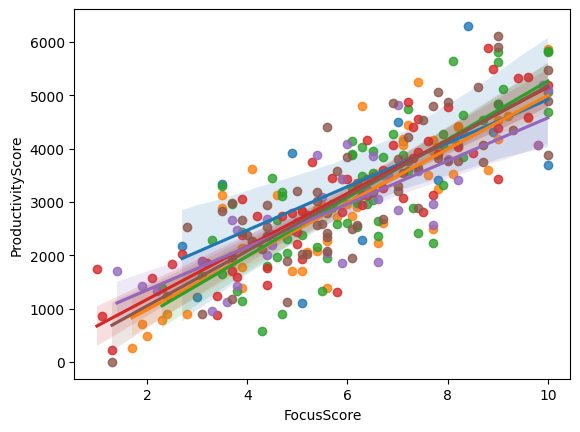

In [44]:
df['Tenure'] = 'New'
df.loc[(df['YearsAtCompany'] >= 1) & (df['YearsAtCompany'] < 5), 'Tenure'] = '1-4 Years'
df.loc[(df['YearsAtCompany'] >= 5) & (df['YearsAtCompany'] < 9), 'Tenure'] = '5-8 Years'
df.loc[(df['YearsAtCompany'] >= 9) & (df['YearsAtCompany'] < 13), 'Tenure'] = '9-12 Years'
df.loc[(df['YearsAtCompany'] >= 13) & (df['YearsAtCompany'] < 16), 'Tenure'] = '13-15 Years'
df.loc[(df['YearsAtCompany'] >= 16), 'Tenure'] = '16+ Years'

sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['Tenure'] == 'New'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['Tenure'] == '1-4 Years'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['Tenure'] == '5-8 Years'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['Tenure'] == '9-12 Years'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['Tenure'] == '13-15 Years'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['Tenure'] == '16+ Years'])

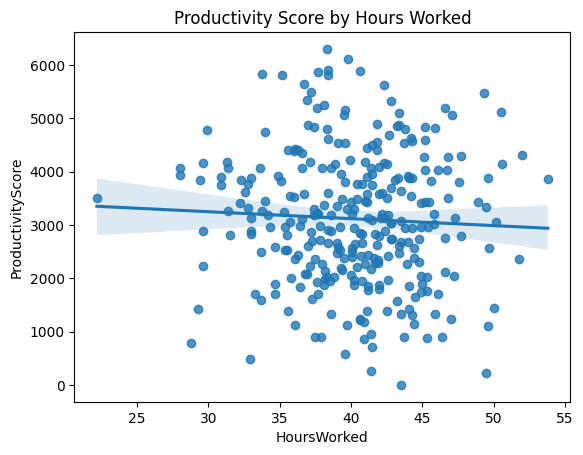

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7768
Date:                Wed, 25 Feb 2026   Prob (F-statistic):              0.379
Time:                        14:47:51   Log-Likelihood:                -2563.7
No. Observations:                 300   AIC:                             5131.
Df Residuals:                     298   BIC:                             5139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3638.4153    599.175      6.072      0.000    2459.265    4817.566
HoursWorked   -13.0329     14.787     -0.881      0.379     -42.133      16.068
==============================================================================
Omnibus:                        2.775   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.250   Jarque-Bera (JB):                2.335
Skew:                           0.104   Prob(JB):                        0.311
Kurtosis:                       2.621   Cond. No.                         337.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
sns.regplot(x='HoursWorked', y='ProductivityScore', data=df)
plt.title('Productivity Score by Hours Worked')
plt.show()

X = sm.add_constant(df['HoursWorked'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

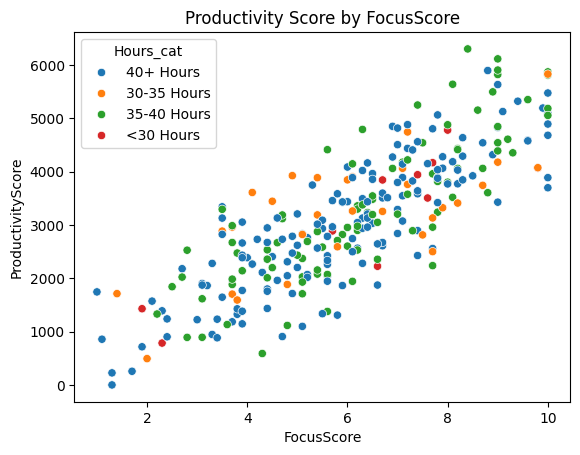

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     312.5
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           8.69e-74
Time:                        14:47:52   Log-Likelihood:                -2394.2
No. Observations:                 300   AIC:                             4794.
Df Residuals:                     297   BIC:                             4806.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         258.8336    366.985      0.705      0.481    -463.386     981.053
FocusScore    494.5564     19.820     24.953      0.000     455.551     533.561
HoursWorked    -3.5345      8.426     -0.419      0.675     -20.117      13.048
==============================================================================
Omnibus:                        0.803   Durbin-Watson:                   2.059
Prob(Omnibus):                  0.669   Jarque-Bera (JB):                0.907
Skew:                           0.072   Prob(JB):                        0.635
Kurtosis:                       2.773   Cond. No.                         366.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [28]:
df['Hours_cat'] = '<30 Hours'
df.loc[(df['HoursWorked'] >= 30) & (df['HoursWorked'] < 35), 'Hours_cat'] = '30-35 Hours'
df.loc[(df['HoursWorked'] >= 35) & (df['HoursWorked'] < 40), 'Hours_cat'] = '35-40 Hours'
df.loc[(df['HoursWorked'] >= 40), 'Hours_cat'] = '40+ Hours'

sns.scatterplot(x='FocusScore', y='ProductivityScore', hue='Hours_cat', data=df)
plt.title('Productivity Score by FocusScore')
plt.show()

X = sm.add_constant(df[['FocusScore', 'HoursWorked']])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

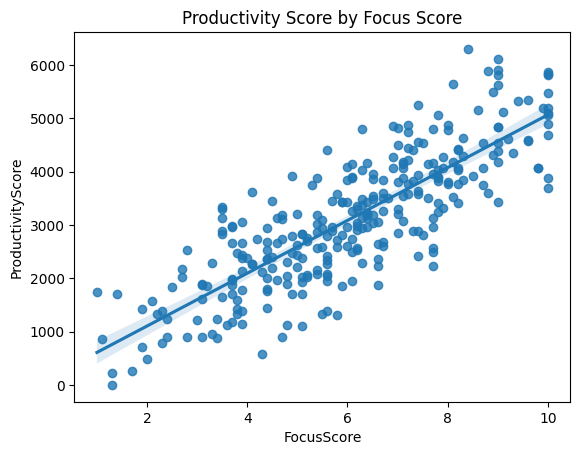

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     626.6
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           3.02e-75
Time:                        14:47:52   Log-Likelihood:                -2394.3
No. Observations:                 300   AIC:                             4793.
Df Residuals:                     298   BIC:                             4800.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        114.3813    126.657      0.903      0.367    -134.874     363.636
FocusScore   494.9319     19.772     25.032      0.000     456.021     533.843
==============================================================================
Omnibus:                        0.756   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.685   Jarque-Bera (JB):                0.869
Skew:                           0.076   Prob(JB):                        0.648
Kurtosis:                       2.784   Cond. No.                         20.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [29]:
sns.regplot(x='FocusScore', y='ProductivityScore', data=df)
plt.title('Productivity Score by Focus Score')
plt.show()

X = sm.add_constant(df['FocusScore'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

In [30]:
df['DeskLocation'] = df['DeskLocation'].map({'Open Plan': 1, 'Private Office': 2, 'Remote': 3})

X = sm.add_constant(df[['FocusScore', 'DeskLocation', 'HoursWorked', 'TeamMeetingsPerWeek']])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.683
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     159.1
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           2.22e-72
Time:                        14:47:52   Log-Likelihood:                -2391.6
No. Observations:                 300   AIC:                             4793.
Df Residuals:                     295   BIC:                             4812.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 284.7560    390.775      0.729      0.467    -484.304    1053.816
FocusScore            511.8345     21.545     23.756      0.000     469.433     554.236
DeskLocation         -111.3525     52.940     -2.103      0.036    -215.541      -7.164
HoursWorked            -3.3486      8.388     -0.399      0.690     -19.857      13.160
TeamMeetingsPerWeek    26.5556     24.749      1.073      0.284     -22.151      75.262
==============================================================================
Omnibus:                        0.255   Durbin-Watson:                   2.035
Prob(Omnibus):                  0.880   Jarque-Bera (JB):                0.393
Skew:                           0.011   Prob(JB):                        0.822
Kurtosis:                       2.824   Cond. No.                         394.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

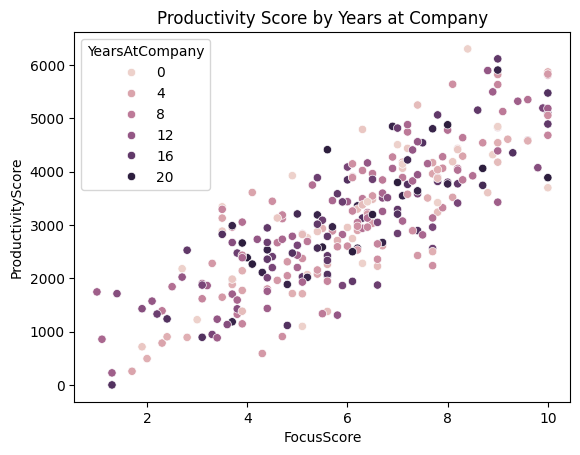

In [31]:
#No correlation between Year at the company and productrivity

sns.scatterplot(x='FocusScore', y='ProductivityScore', data=df, hue='YearsAtCompany')
plt.title('Productivity Score by Years at Company')
plt.show()

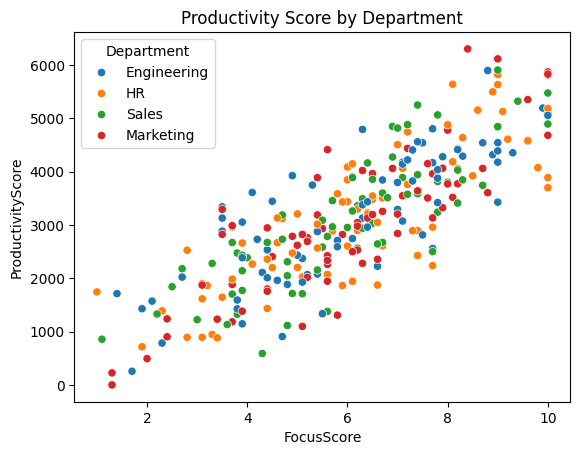

In [32]:
#No correlation between Department and productivity

sns.scatterplot(x='FocusScore', y='ProductivityScore', data=df, hue='Department')
plt.title('Productivity Score by Department')
plt.show()

<Axes: xlabel='FocusScore', ylabel='ProductivityScore'>

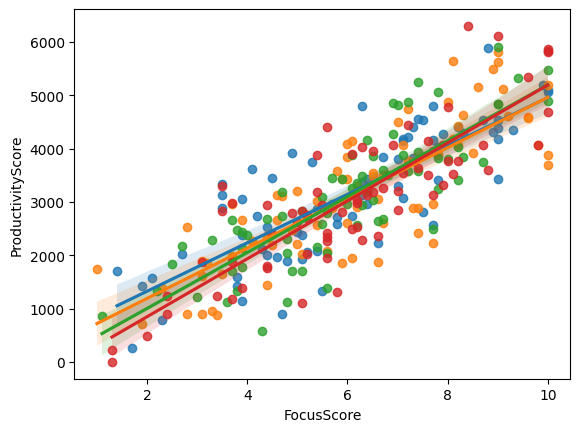

In [33]:
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['Department'] == 'Engineering'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['Department'] == 'HR'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['Department'] == 'Sales'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['Department'] == 'Marketing'])

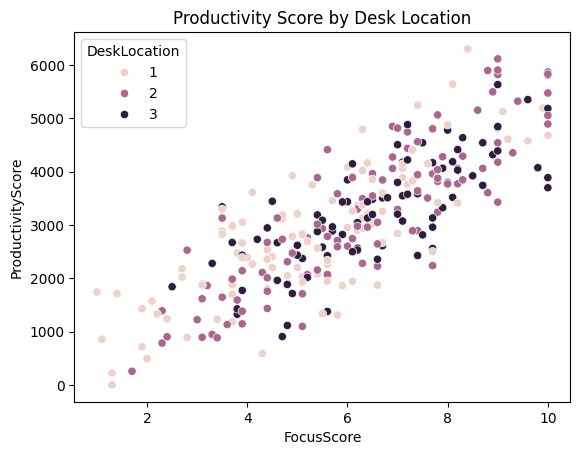

In [34]:
sns.scatterplot(x='FocusScore', y='ProductivityScore', data=df, hue='DeskLocation')
plt.title('Productivity Score by Desk Location')
plt.show()

<Axes: xlabel='FocusScore', ylabel='ProductivityScore'>

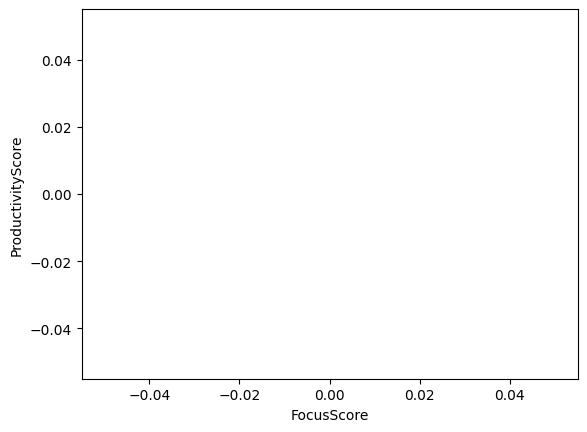

In [35]:
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['DeskLocation'] == 'Open Plan'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['DeskLocation'] == 'Private Office'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['DeskLocation'] == 'Remote'])

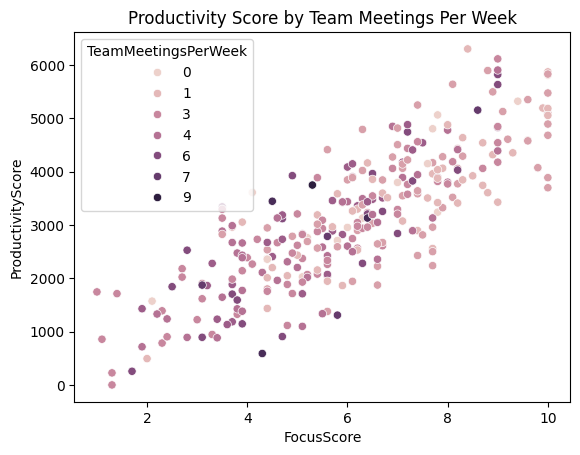

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     17.09
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           4.63e-05
Time:                        14:47:53   Log-Likelihood:                -2555.8
No. Observations:                 300   AIC:                             5116.
Df Residuals:                     298   BIC:                             5123.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                3611.2745    139.247     25.934      0.000    3337.243    3885.306
TeamMeetingsPerWeek  -165.5197     40.036     -4.134      0.000    -244.309     -86.730
==============================================================================
Omnibus:                        2.592   Durbin-Watson:                   1.991
Prob(Omnibus):                  0.274   Jarque-Bera (JB):                2.468
Skew:                           0.157   Prob(JB):                        0.291
Kurtosis:                       2.686   Cond. No.                         7.33
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [36]:
sns.scatterplot(x='FocusScore', y='ProductivityScore', data=df, hue='TeamMeetingsPerWeek')
plt.title('Productivity Score by Team Meetings Per Week')
plt.show()

X = sm.add_constant(df['TeamMeetingsPerWeek'])
y = df['ProductivityScore']

model = sm.OLS(y, X).fit()

model.summary()

<Axes: xlabel='FocusScore', ylabel='ProductivityScore'>

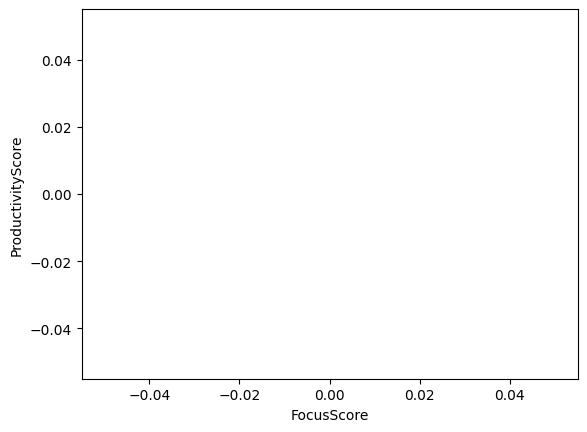

In [37]:
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['TeamMeetingsPerWeek'] == '0'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['TeamMeetingsPerWeek'] == '1'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['TeamMeetingsPerWeek'] == '3'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['TeamMeetingsPerWeek'] == '4'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['TeamMeetingsPerWeek'] == '6'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['TeamMeetingsPerWeek'] == '7'])
sns.regplot(x='FocusScore', y='ProductivityScore', data=df.loc[df['TeamMeetingsPerWeek'] == '9'])